LOAD LIBS

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as torchF
from torchvision import models
import cv2
from torchvision import transforms

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## FOR LEGACY MODEL

In [3]:
class Encoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.backbone = models.resnet50(pretrained=False)
        self.backbone.fc = nn.Linear(2048, embed_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x

In [4]:
model = Encoder().to(DEVICE)

state_dict = torch.load(r"sketch_matcher.pth", map_location=DEVICE)
model.load_state_dict(state_dict)

model.eval()
print("✅ Model loaded successfully")

d:\Python\Netra-X\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Python\Netra-X\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'sketch_matcher.pth'

In [ ]:
transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

## DO PHOTO EMBEDINGS

In [27]:
import os

sketch_dir = r"../dataset/sketches"
photo_dir = r"../dataset/photos"

# Extract valid sketch IDs
valid_ids = []

for fname in os.listdir(sketch_dir):
    if fname.endswith(".jpg"):
        valid_ids.append(fname.split("-01")[0])

print("Valid sketch identities:", len(valid_ids))

Valid sketch identities: 188


In [28]:
# Filter photos
filtered_photos = []

for fname in os.listdir(photo_dir):
    if not fname.endswith(".jpg"):
        continue

    # Example: m-012.jpg
    photo_id = fname.split("-01")[0]

    if photo_id in valid_ids:
        filtered_photos.append(fname)

print("Photos used for evaluation:", len(filtered_photos))

Photos used for evaluation: 188


In [29]:
filtered_photos[0]

'f-005-01.jpg'

In [30]:
import os

photo_dir = r"../dataset/photos"

photo_embeddings = []
photo_paths = []

with torch.no_grad():
    for fname in os.listdir(photo_dir):
        if not fname.endswith(".jpg"):
            continue

        path = os.path.join(photo_dir, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = transform(img).to(DEVICE)

        emb = model(img.unsqueeze(0))
        photo_embeddings.append(emb.cpu())
        photo_paths.append(path)

photo_embeddings = torch.cat(photo_embeddings)
print("✅ Photo database indexed")


✅ Photo database indexed


## FOR TRIPLET LOSS

In [3]:
# ===== CONFIG =====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
EMBED_DIM = 128

BATCH_SIZE = 8
EPOCHS = 25
LR_HEAD = 1e-4
LR_BACKBONE = 1e-5

MARGIN = 0.5
SEED = 42


In [4]:
class Encoder(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)
        self.backbone.fc = nn.Linear(2048, embed_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = torchF.normalize(x, p=2, dim=1)
        return x

In [14]:
model = Encoder().to(DEVICE)

state_dict = torch.load(r"models\colab\sketch_photo_triplet_modelV2.pth", map_location=DEVICE)
model.load_state_dict(state_dict)

model.eval()
print("✅ Model loaded successfully")

d:\Python\Netra-X\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Python\Netra-X\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Model loaded successfully


In [15]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

TESTING

In [ ]:
#legacy Recognizer
def recognize_sketch(sketch_path):
    img = cv2.imread(sketch_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = transform(img).to(DEVICE)

    with torch.no_grad():
        sketch_emb = model(img.unsqueeze(0))
        sims = torchF.cosine_similarity(sketch_emb.cpu(), photo_embeddings)

    best_idx = torch.argmax(sims).item()
    return photo_paths[best_idx], sims[best_idx].item()


In [75]:
def match_sketch(sketch_path):
    model.eval()

    # --- Load & preprocess sketch ---
    img = cv2.imread(sketch_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = transform(img).to(DEVICE)

    with torch.no_grad():
        sketch_emb = model(img.unsqueeze(0))
        sims = torchF.cosine_similarity(sketch_emb.cpu(), photo_embeddings)

    # --- Top-K ranking ---
    topk = torch.topk(sims, k=5)

    best_idx = topk.indices[0].item()
    best_score = topk.values[0].item()
    second_score = topk.values[1].item()

    best_photo = photo_paths[best_idx]

    # --- Metric 1: Similarity gap ---
    # gap = best_score - second_score
    gap = best_score / (second_score + 1e-8)

    # --- Metric 2: Z-score normalization ---
    mean = sims.mean().item()
    std = sims.std().item() + 1e-8  # avoid divide-by-zero
    z_score = (best_score - mean) / std

    # --- Metric 3: Percentile rank ---
    percentile = (sims < best_score).float().mean().item()

    # --- Final decision logic ---
    is_match = (
        best_score > 0.30 and
        gap < 1.06 and
        z_score > 1.5
    )

    return {
        "match_found": is_match,
        "best_photo": best_photo,
        "similarity": round(best_score, 3),
        "gap": round(gap, 3),
        "z_score": round(z_score, 2),
        "percentile": round(percentile, 3),
        "top5_photos": [photo_paths[i] for i in topk.indices.tolist()]
    }


In [ ]:
#not working
import cv2

img = cv2.imread(r"..\dataset\image3.jpeg", cv2.IMREAD_GRAYSCALE)

# add slight noise
noise = cv2.randn(img.copy(), 0, 10)
img_noisy = cv2.add(img, noise)

# blur slightly
img_blur = cv2.GaussianBlur(img_noisy, (3,3), 0)

cv2.imwrite(r"..\dataset\new_image3.jpg", img_blur)


True

{'match_found': False, 'best_photo': '../dataset/photos\\f1-013-01.jpg', 'similarity': 0.45, 'gap': 1.092, 'z_score': 3.36, 'percentile': 0.995, 'top5_photos': ['../dataset/photos\\f1-013-01.jpg', '../dataset/photos\\f1-006-01.jpg', '../dataset/photos\\f-021-01.jpg', '../dataset/photos\\f1-014-01.jpg', '../dataset/photos\\f-027-01.jpg']}
Matched photo: ../dataset/photos\f1-013-01.jpg
Similarity score: 0.45


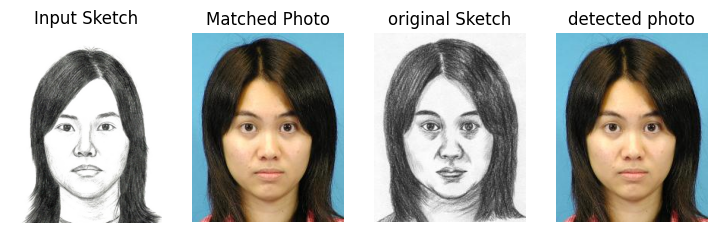

In [76]:
import matplotlib.pyplot as plt


r"..\dataset\sketches\f1-007-01-sz1.jpg"
r"..\dataset\new_image3.jpg"

sketch_path = r"..\dataset\image4.jpeg" # your test sketch
original_sketch_dir = r"../dataset/sketches/"

res = match_sketch(sketch_path)
print(res)
top5 = res["top5_photos"]
best_photo = res["best_photo"]
score = res["similarity"]

original_sketch_path = original_sketch_dir + best_photo[18:-4] + "-sz1.jpg"

res = match_sketch(original_sketch_path)
best_photo2 = res["best_photo"]
score2 = res["similarity"]

print("Matched photo:", best_photo)
print("Similarity score:", score)

plt.figure(figsize=(9,3))

plt.subplot(1,4,1)
plt.title("Input Sketch")
plt.imshow(cv2.cvtColor(cv2.imread(sketch_path), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Matched Photo")
plt.imshow(cv2.cvtColor(cv2.imread(best_photo), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,3)
plt.title("original Sketch")
plt.imshow(cv2.cvtColor(cv2.imread(original_sketch_path), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,4)
plt.title("detected photo")
plt.imshow(cv2.cvtColor(cv2.imread(best_photo2), cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()


In [26]:
original_sketch_path

'../dataset/sketches/m-021-01-sz1.jpg'

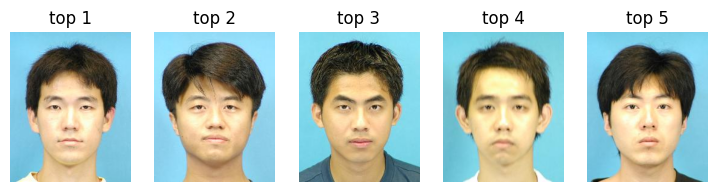

In [69]:
#top 5
plt.figure(figsize=(9,3))
num = len(top5)
for i,p in enumerate(top5):
  plt.subplot(1,num,i+1)
  plt.title(f"top {i+1}")
  plt.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
  plt.axis("off")